In [1]:
from dlfs.base import Module, Loss
from dlfs.layers import DenseLayer, ReshapeLayer, ConvLayer, ConvTransposeLayer, BatchNorm2D, DropoutLayer
from dlfs.activation import ReLU, LeakyReLU, Tanh, Sigmoid
from dlfs.modules import SequentialWrapper
from dlfs.helpers import DLFSData, get_random_batch
from dlfs.optimizers import Optimizer_Adam
from dlfs.loss import BCE_Loss, MSE_Loss

import numpy as np
import matplotlib.pyplot as plt

In [2]:
class DCGenerator(Module):

    def __init__(self, latent_dim, features):

        self.latent_dim = latent_dim
        self.features = features
    
        self.model = SequentialWrapper([

                # Z → (ngf*4) × 4 × 4
                ConvTransposeLayer(
                    input_channels=latent_dim,
                    output_channels=features * 4,
                    kernel_size=4,
                    stride=1,
                    padding=0
                ),
                BatchNorm2D(features * 4),
                ReLU(),

                # 4×4 → 7×7
                ConvTransposeLayer(
                    input_channels=features * 4,
                    output_channels=features * 2,
                    kernel_size=3,
                    stride=2,
                    padding=1
                ),
                BatchNorm2D(features * 2),
                ReLU(),

                # 7×7 → 14×14
                ConvTransposeLayer(
                    input_channels=features * 2,
                    output_channels=features,
                    kernel_size=4,
                    stride=2,
                    padding=1
                ),
                BatchNorm2D(features),
                ReLU(),

                # 14×14 → 28×28  (final MNIST resolution)
                ConvTransposeLayer(
                    input_channels=features,
                    output_channels=1,
                    kernel_size=4,
                    stride=2,
                    padding=1
                ),

                Sigmoid()
            ])


    def forward(self, x, training=False):
        self.model.forward(x, training=training)
        self.output = self.model.output

    def backward(self, delta):
        self.model.backward(delta)
        self.dinputs = self.model.dinputs.copy()

In [3]:
class MLPGenerator(Module):

    def __init__(self, latent_dim):

        self.latent_dim = latent_dim

        self.model = SequentialWrapper(
            [
                DenseLayer(latent_dim, 256),
                ReLU(),
                DenseLayer(256, 512),
                ReLU(),
                DenseLayer(512, 1024),
                ReLU(),
                DenseLayer(1024, 28*28),
                ReshapeLayer(input_shape=(28*28, ), output_shape=(1, 28, 28)),
                Sigmoid()
            ])

    def forward(self, x, training=False):
        self.model.forward(x, training=training)
        self.output = self.model.output

    def backward(self, delta):
        self.model.backward(delta)
        self.dinputs = self.model.dinputs.copy()

In [4]:
class MLPDiscriminator(Module):

    def __init__(self):

        self.model = SequentialWrapper(
            [
                ReshapeLayer(input_shape=(1, 28, 28), output_shape=(28*28, )),
                DenseLayer(28*28, 32),
                #DropoutLayer(0.1),
                ReLU(),
                DenseLayer(32, 1),
                #DropoutLayer(0.1),
            ]
        )
    
    def forward(self, x, training=False):
        self.model.forward(x, training=training)
        self.output = self.model.output

    def backward(self, delta):
        self.model.backward(delta)
        self.dinputs = self.model.dinputs.copy()

In [5]:
class DCDiscriminator(Module):

    def __init__(self, features):

        self.features = features

        """
        nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf) x 32 x 32``
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*2) x 16 x 16``
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*4) x 8 x 8``
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*8) x 4 x 4``
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()



            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False), 
            nn.LeakyReLU(0.2, inplace=True),
            # state: (ndf) x 14 x 14

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state: (ndf*2) x 7 x 7

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state: (ndf*4) x 4 x 4

            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        """

        self.model = SequentialWrapper([
                ConvLayer(input_channels=1, output_channels=features, kernel_size=4, stride=2, padding=1),
                LeakyReLU(0.2),

                ConvLayer(input_channels=features, output_channels=features*2, kernel_size=4, stride=2, padding=1),
                #BatchNorm2D(features*2),
                LeakyReLU(0.2),

                ConvLayer(input_channels=features*2, output_channels=features*4, kernel_size=3, stride=2, padding=1),
                #BatchNorm2D(features*4),
                LeakyReLU(0.2),

                ConvLayer(input_channels=features*4, output_channels=1, kernel_size=4, stride=1, padding=0),
                ReshapeLayer(input_shape=(1, 1, 1), output_shape=(1, )),
                #Sigmoid()
        ])
    
    def forward(self, x, training=False):
        self.model.forward(x, training=training)
        self.output = self.model.output

    def backward(self, delta):
        self.model.backward(delta)
        self.dinputs = self.model.dinputs.copy()

In [6]:
class BCE_Loss_Saturated(Loss):

    def __init__(self, from_logits=True) -> None:
        self.from_logits = from_logits

    def calculate(self, y_pred: np.ndarray) -> float:
        if self.from_logits:
            # y_pred are logits: use softplus(-logits)
            # L = log(1 + exp(-logits))
            loss = np.log1p(np.exp(-y_pred))
        else:
            # y_pred are probabilities in (0,1)
            # L = -log(y_pred)
            y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
            loss = -np.log(y_pred_clipped)

        return np.mean(loss)

    def backward(self, y_pred: np.ndarray) -> None:
        if self.from_logits:
            # logits: d/dx softplus(-x) = -sigmoid(-x)
            sig = 1 / (1 + np.exp(y_pred))  # sigmoid(-logits)
            self.dinputs = -sig / y_pred.shape[0]

        else:
            # probabilities: d/dx -log(x) = -1/x
            y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
            self.dinputs = -1 / (y_pred_clipped * y_pred.shape[0])


In [7]:
class GAN(Module):

    def __init__(self, generator, discriminator, loss_fn, loss_fn_sat, optimizer_g, optimizer_d):
        self.generator = generator
        self.discriminator = discriminator
        self.loss_fn = loss_fn
        self.loss_fn_sat = loss_fn_sat
        self.optimizer_g = optimizer_g
        self.optimizer_d = optimizer_d

    def _generator_forward_step(self, batch_size: int, real_labels: np.ndarray, training=False):
        # Create random latent variables
        z = np.random.randn(batch_size, self.generator.latent_dim, 1, 1)
        #z = np.random.uniform(low=-1.0, high=1.0, size=(batch_size, self.generator.latent_dim))

        # Generate fake samples
        self.generator.forward(z, training=training)
        generated_fake = self.generator.output.copy()

        # Let discriminator guess
        self.discriminator.forward(generated_fake, training=training)
        discriminator_output = self.discriminator.output.copy() #(B, 1)

        # Calculate generator loss (compare fake with real)
        generator_loss = self.loss_fn_sat.calculate(discriminator_output)

        return generator_loss, discriminator_output.copy()

    def _generator_backward_step(self, discriminator_output, real_labels):
        self.loss_fn_sat.backward(discriminator_output)
        #print(f'loss fn sat grad: {np.linalg.norm(self.loss_fn_sat.dinputs)}')
        self.discriminator.backward(self.loss_fn_sat.dinputs)
        #print(f'discriminator grad: {np.linalg.norm(self.discriminator.dinputs)}')
        self.generator.backward(self.discriminator.dinputs)
        #print(f'generator grad: {np.linalg.norm(self.generator.dinputs)}')

    def _discriminator_forward_step(self, X, real_labels: np.ndarray, fake_labels: np.ndarray, noise=0.1, training=False):

        batch_size = X.shape[0]

        # Create random latent variables
        z = np.random.randn(batch_size, self.generator.latent_dim, 1, 1)
        #z = np.random.uniform(low=-1.0, high=1.0, size=(batch_size, self.generator.latent_dim))

        # Generate fake samples
        self.generator.forward(z, training=training)
        generated_fake = self.generator.output.copy()

        # Combine real and fake samples
        X_combined = np.concatenate([X, generated_fake])
        y_combined = np.concatenate([real_labels, fake_labels]) 

        idx = np.random.permutation(len(X_combined))
        X_combined = X_combined[idx]
        y_combined = y_combined[idx]

        X_combined += np.random.randn(*X_combined.shape) * noise

        # Let discriminator guess both real and fake
        self.discriminator.forward(X_combined, training=training)
        combined_output = self.discriminator.output.copy() #(B, 1)

        #print(f'disc output: {combined_output.shape}')

        # Calculate discriminator loss
        discriminator_loss = self.loss_fn.calculate(combined_output, y_combined)
        return discriminator_loss, combined_output.copy(), y_combined.copy()

    def _discriminator_backward_step(self, discriminator_output, labels):
        self.loss_fn.backward(discriminator_output, labels)
        self.discriminator.backward(self.loss_fn.dinputs)
    
    def train(self, X: np.ndarray, epochs: int = 1000, batch_size: int = None, print_every: int = None) -> None:

        for i in range(epochs + 1):

            if batch_size is None:
                batch_size = X.shape[0]

            X_batch = get_random_batch(X, batch_size=batch_size)[0]
            b_size = X_batch.shape[0]  # actual batch size

            # Labels
            real = np.ones((b_size, 1))
            fake = np.zeros((b_size, 1))

            # Discriminator forward-backward step
            dis_loss, dis_out, combined_labels = self._discriminator_forward_step(X_batch, real * 0.9, fake, noise=0.01, training=True)
            self._discriminator_backward_step(dis_out, combined_labels)

            # Discriminator parameter update
            self.optimizer_d.pre_update_parameters()
            self.optimizer_d.update_parameters(self.discriminator)
            self.optimizer_d.post_update_parameters()

            # Train generator twice per epoch
            for _ in range(2):
                
                # Generator forward-backward step
                gen_loss, dis_out = self._generator_forward_step(b_size, real, training=True)
                self._generator_backward_step(dis_out, real)

                # Generator parameter update
                self.optimizer_g.pre_update_parameters()
                self.optimizer_g.update_parameters(self.generator)
                self.optimizer_g.post_update_parameters()

            if print_every is not None:

                real = np.ones((X.shape[0], 1))
                fake = np.zeros((X.shape[0], 1))

                # Validation Gen
                gen_loss, dis_out = self._generator_forward_step(X.shape[0], real)

                # Validation Disc
                dis_loss, dis_out, combined_labels = self._discriminator_forward_step(X, real, fake, noise=0.0)

                if not i % print_every:
                    print(f'===== EPOCH : {i} ===== LOSS DIS : {dis_loss:.5f} ===== LOSS GEN : {gen_loss:.5f}')

# Load data

In [8]:
np.random.seed(1)

mnist_path = "../data/mnist"

X_train, y_train, X_test, y_test = DLFSData.load_MNIST(mnist_path)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

X_train: (60000, 28, 28), y_train: (60000,)
X_test: (10000, 28, 28), y_test: (10000,)


In [9]:
# Selecting images of 3s and 7s
X_train, _ = DLFSData.select_MNIST_labels(X_train, y_train, labels=[0], limit=1000, shuffle=True)
X_train = DLFSData.normalize_MNIST(X_train, range=(0, 1))

X_train = X_train.reshape(-1, 1, 28, 28)
print(f'X_train: {X_train.shape}')

X_train: (1000, 1, 28, 28)


In [10]:
latent_dim = 100 # 128 radi
generator_features = 64
discriminator_features = 16

lr = 2e-3 # learning rate dobar je 2e-3
epochs = 500
batch_size = 64 # 64 radi, batches je potreban

gen = DCGenerator(latent_dim=latent_dim, features=generator_features)
dis = DCDiscriminator(features=discriminator_features)

gan = GAN(generator=gen, 
          discriminator=dis, 
          loss_fn=BCE_Loss(from_logits=True),
          loss_fn_sat=BCE_Loss_Saturated(from_logits=True),
          optimizer_g=Optimizer_Adam(learning_rate=2e-3, beta_1=0.5),
          optimizer_d=Optimizer_Adam(learning_rate=2e-3, beta_1=0.5)) #beta1=0.5 !!

gan.train(X_train, epochs=epochs, print_every=1, batch_size=batch_size)

===== EPOCH : 0 ===== LOSS DIS : 0.67991 ===== LOSS GEN : 0.72469
===== EPOCH : 1 ===== LOSS DIS : 0.66271 ===== LOSS GEN : 0.74649
===== EPOCH : 2 ===== LOSS DIS : 0.63965 ===== LOSS GEN : 0.75277
===== EPOCH : 3 ===== LOSS DIS : 0.61077 ===== LOSS GEN : 0.73928
===== EPOCH : 4 ===== LOSS DIS : 0.58490 ===== LOSS GEN : 0.68531
===== EPOCH : 5 ===== LOSS DIS : 0.56665 ===== LOSS GEN : 0.70674
===== EPOCH : 6 ===== LOSS DIS : 0.56089 ===== LOSS GEN : 0.71509
===== EPOCH : 7 ===== LOSS DIS : 0.56456 ===== LOSS GEN : 0.74483
===== EPOCH : 8 ===== LOSS DIS : 0.56817 ===== LOSS GEN : 0.76726
===== EPOCH : 9 ===== LOSS DIS : 0.60533 ===== LOSS GEN : 0.49273
===== EPOCH : 10 ===== LOSS DIS : 0.79318 ===== LOSS GEN : 1.14466
===== EPOCH : 11 ===== LOSS DIS : 0.55577 ===== LOSS GEN : 0.72295
===== EPOCH : 12 ===== LOSS DIS : 0.60824 ===== LOSS GEN : 0.48639
===== EPOCH : 13 ===== LOSS DIS : 0.59187 ===== LOSS GEN : 0.64505
===== EPOCH : 14 ===== LOSS DIS : 0.64223 ===== LOSS GEN : 0.91494
=====

KeyboardInterrupt: 

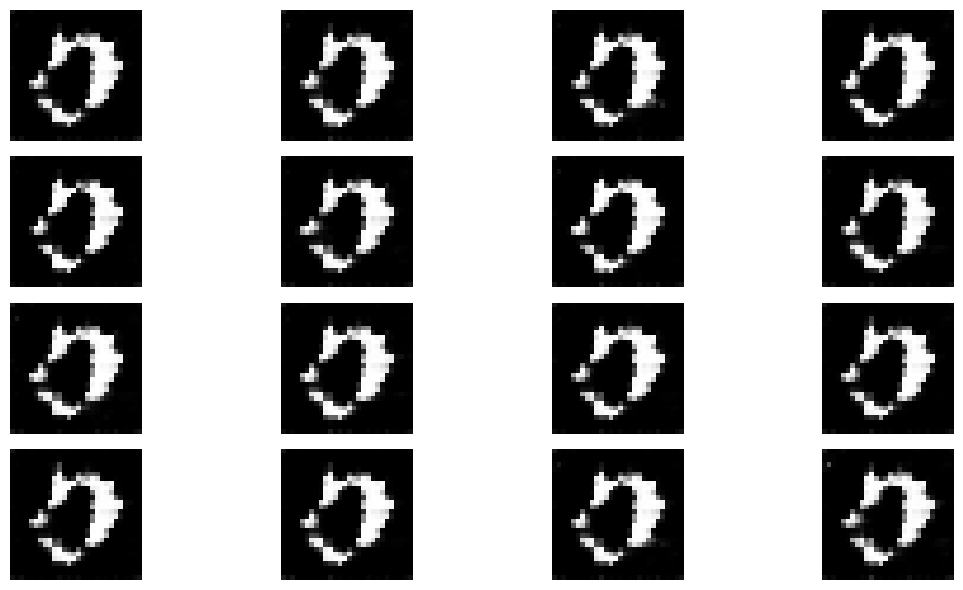

In [11]:
num_img = 16

fig, axes = plt.subplots(4, 4, figsize=(12, 6))
axes = axes.flatten()

# Sample from random normal
Z = np.random.randn(num_img, gan.generator.latent_dim, 1, 1)

# Pass through decoder to reconstruct
gan.generator.forward(Z)

# Generate and plot n images
for i in range(num_img):
    img = gan.generator.output[i].reshape(28, 28)  # Reshape the output to 28x28 image
    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()